# De combien la Terre ment-elle dans les dix premières minutes ?

Quand un séisme se produit, l'USGS publie en moins de deux minutes une magnitude
calculée automatiquement. Des heures — parfois des mois — plus tard, un
sismologue la révise. L'écart entre les deux décide d'une évacuation, d'une
alerte tsunami, d'une mobilisation de secours.

Ce carnet lit **directement les tables Gold en Parquet depuis HDFS**, sans Spark
et sans recalcul : tout ce qui suit a été produit par les jobs de la couche
Gold, orchestrés par Airflow.

In [1]:
import sys
sys.path.insert(0, "/opt/app")
import json

import pandas as pd
import matplotlib.pyplot as plt

from src.common.config import GOLD_ROOT
from src.common.gold_reader import available_tables, load
from src.common.hdfs import WebHdfs

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

fs = WebHdfs()
fs.wait_ready()

print("Tables Gold disponibles sur HDFS :")
for name in available_tables(fs):
    print("   ", name)

Tables Gold disponibles sur HDFS :
    alert_curve
    alert_reliability
    human_witness
    identity_history
    lake_diff
    magnitude_revision
    magnitude_scales
    model_export
    model_report
    review_lag
    revision_history
    site_bundle.json


In [2]:
revisions = load("revision_history", fs)
identity = load("identity_history", fs)
scales = load("magnitude_scales", fs)
lag = load("review_lag", fs)

pairs = load("magnitude_revision", fs)
curve = load("alert_curve", fs)
witness = load("human_witness", fs)

report = json.loads(fs.read(f"{GOLD_ROOT}/model_report/report.json"))

for name, frame in [("revision_history", revisions), ("identity_history", identity),
                    ("magnitude_scales", scales), ("review_lag", lag),
                    ("magnitude_revision", pairs), ("alert_curve", curve),
                    ("human_witness", witness)]:
    print(f"{name:<22} {len(frame):>7} lignes")

revision_history             2 lignes
identity_history         17536 lignes
magnitude_scales             8 lignes
review_lag                   7 lignes
magnitude_revision        2128 lignes
alert_curve                 41 lignes
human_witness             2128 lignes


---
## 1. De combien la magnitude bouge-t-elle, et en combien de temps ?

Deux mesures répondent à cette question, et elles ne disent pas la même chose.

La première est **directe** : les séismes que notre flux a vus changer sous nos
yeux. Elle est exacte mais son volume dépend du temps d'écoute du flux.

La seconde est **rétrospective** : le délai entre l'instant du séisme et la
dernière modification de sa fiche, lisible sur les 17 536 séismes du catalogue.

In [3]:
print("MESURE DIRECTE — séismes dont notre flux a capté plusieurs versions")
if len(revisions):
    display(revisions[["event_key", "place", "first_magnitude", "final_magnitude",
                       "magnitude_shift", "first_status", "final_status",
                       "minutes_to_final", "versions"]])
else:
    print("  aucune révision captée pour l'instant")

print()
print("Le flux tourne depuis peu : cette table s'enrichit d'elle-même à chaque")
print("heure d'écoute. Elle est la seule mesure EXACTE de l'écart.")

MESURE DIRECTE — séismes dont notre flux a capté plusieurs versions


,event_key,place,first_magnitude,final_magnitude,magnitude_shift,first_status,final_status,minutes_to_final,versions
0,ok2026qsuv,"4 km SE of Ratliff City, Oklahoma",2.11,1.87,-0.24,automatic,reviewed,35.2,3
1,tx2026quwnvj,"35 km WSW of Mentone, Texas",1.90,1.90,0.00,automatic,automatic,0.6,2



Le flux tourne depuis peu : cette table s'enrichit d'elle-même à chaque
heure d'écoute. Elle est la seule mesure EXACTE de l'écart.


,review_status,magnitude_family,events,lag_median_minutes,lag_median_hours,lag_median_days
0,reviewed,body_wave,15614,110563.5,1842.7,76.8
1,reviewed,moment,1817,110610.7,1843.5,76.8
2,reviewed,local,70,118076.9,1967.9,82.0
3,reviewed,duration,26,104351.9,1739.2,72.5
4,automatic,duration,4,1.6,0.0,0.0
5,automatic,local,4,3.5,0.1,0.0
6,reviewed,surface_wave,1,107087.3,1784.8,74.4


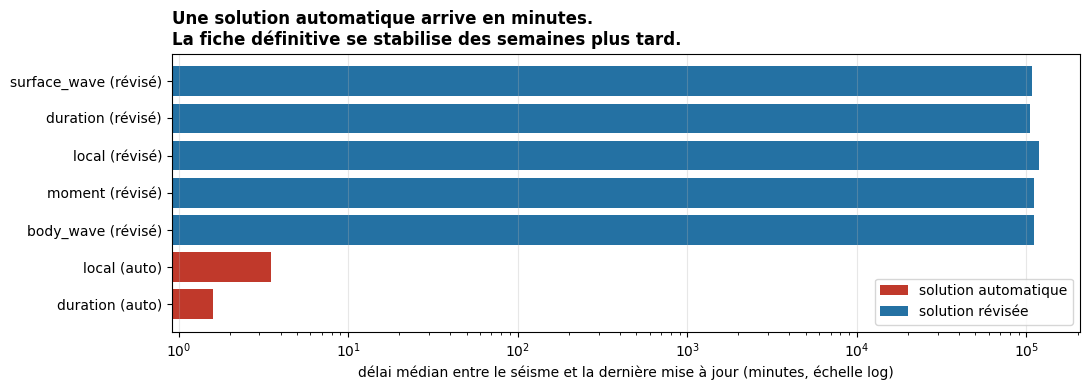

In [4]:
publication = lag.copy()
publication["lag_median_hours"] = (publication["lag_median_minutes"] / 60).round(1)
publication["lag_median_days"] = (publication["lag_median_minutes"] / 1440).round(1)

display(publication[["review_status", "magnitude_family", "events",
                     "lag_median_minutes", "lag_median_hours", "lag_median_days"]])

automatic = publication[publication.review_status == "automatic"]
reviewed = publication[publication.review_status == "reviewed"]

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(automatic.magnitude_family + " (auto)", automatic.lag_median_minutes,
        color="#c0392b", label="solution automatique")
ax.barh(reviewed.magnitude_family + " (révisé)", reviewed.lag_median_minutes,
        color="#2471a3", label="solution révisée")
ax.set_xscale("log")
ax.set_xlabel("délai médian entre le séisme et la dernière mise à jour (minutes, échelle log)")
ax.set_title("Une solution automatique arrive en minutes.\n"
             "La fiche définitive se stabilise des semaines plus tard.",
             fontweight="bold", loc="left")
ax.legend()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

> **Lecture.** L'échelle est logarithmique, sinon les barres automatiques
> seraient invisibles. Le rapport entre les deux régimes se compte en dizaines
> de milliers.
>
> **Précaution.** Le champ `updated` marque la dernière modification de la
> fiche, quelle qu'en soit la raison — révision de magnitude, mais aussi ajout
> d'un ShakeMap ou de signalements citoyens. Ce délai est donc une borne
> supérieure du temps de révision, pas le temps de révision lui-même.

---
## 2. Les réseaux sont-ils d'accord ? La question mal posée, et la bonne

Le brief de départ supposait que plusieurs réseaux déclarent le même séisme
séparément, et qu'il fallait les déduplider. **Vérification faite, c'est faux** :
sur 252 événements du flux, aucun alias n'apparaît comme événement distinct.
L'USGS fusionne déjà côté serveur.

Le vrai désaccord est ailleurs, et il est plus intéressant : **l'identité de
l'événement change dans le temps**. La solution automatique porte un identifiant
`usauto…`, la solution révisée un identifiant `us…`. Même séisme, deux noms.

In [5]:
traced = identity[identity.automatic_origin]
changed = identity[identity.identity_changed]

print(f"séismes au catalogue                         : {len(identity):>6}")
print(f"portant la trace d'une solution automatique  : {len(traced):>6} "
      f"({len(traced)/len(identity):.1%})")
print(f"dont l'identifiant retenu a changé depuis    : {len(changed):>6}")
print()
print("Chacun de ces séismes aurait été compté DEUX FOIS par une jointure sur")
print("`id` : une fois comme alerte automatique disparue, une fois comme")
print("événement révisé surgi de nulle part.")
print()

display(traced[["event_key", "usgs_id", "all_ids", "networks", "magnitude",
                "magnitude_type", "place"]].head(8))

séismes au catalogue                         :  17536
portant la trace d'une solution automatique  :   1151 (6.6%)
dont l'identifiant retenu a changé depuis    :   1151

Chacun de ces séismes aurait été compté DEUX FOIS par une jointure sur
`id` : une fois comme alerte automatique disparue, une fois comme
événement révisé surgi de nulle part.



,event_key,usgs_id,all_ids,networks,magnitude,magnitude_type,place
0,at00svnbao,us7000pwpu,"[at00svnbao, at00svnbaq, pt25122002, us7000pwp...","[at, usauto, us, pt, at, usauto]",6.40,mww,"289 km SSE of Ushuaia, Argentina"
1,at00supwy4,ci40925991,"[at00supwy4, ci40925991, ew1744650510, pt25104...","[ew, ci, us, at, usauto, pt]",5.21,mw,"5 km S of Julian, CA"
2,ak02598saaqj,us7000qe51,"[ak02598saaqj, at00szpyen, pt25201004, us7000q...","[at, us, usauto, pt, ak]",6.20,mww,"91 km SSE of Sand Point, Alaska"
3,ak025bb6gdes,us7000qtm0,"[ak025bb6gdes, at00t2168g, pt25246000, us7000q...","[at, ak, us, usauto, pt]",5.90,mww,"92 km SSW of Nikolski, Alaska"
4,ak025dxe5mlz,ak025dxe5mlz,"[ak025dxe5mlz, at00t4ygrd, pt25303000, us6000r...","[ak, at, usauto, pt, us]",5.40,ml,"48 km ESE of Fox River, Alaska"
5,ak0252mj9f2p,us6000pvm4,"[ak0252mj9f2p, at00ssat5y, pt25057001, us6000p...","[usauto, at, pt, us, ak]",5.80,mww,"153 km ESE of Ust’-Kamchatsk Staryy, Russia"
6,ak025925029r,us7000qd1y,"[ak025925029r, at00sziems, pt25197050, us7000q...","[at, us, pt, usauto, ak]",7.30,mww,"2025 Sand Point, Alaska Earthquake"
7,pr2025217000,pr2025217000,"[pr2025217000, pt25217001, us6000qy7q, usauto6...","[usauto, pr, us, usauto, pt]",5.70,ml,"38 km SE of Boca de Yuma, Dominican Republic"


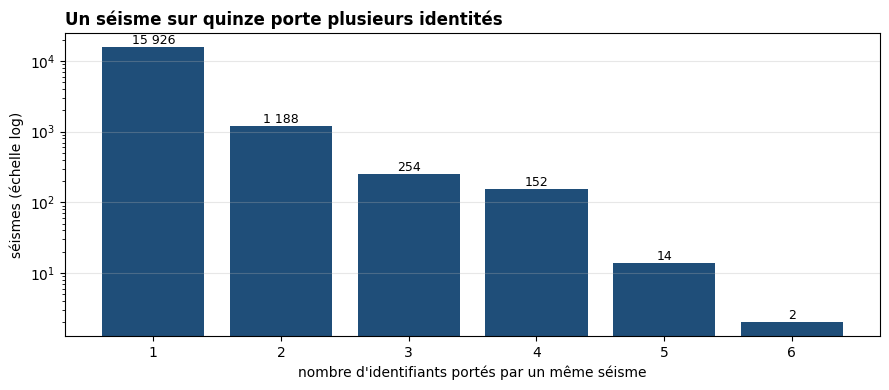

In [6]:
distribution = identity.identifier_count.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(distribution.index.astype(str), distribution.values, color="#1f4e79")
for x, y in zip(range(len(distribution)), distribution.values):
    ax.text(x, y, f"{y:,}".replace(",", " "), ha="center", va="bottom", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel("nombre d'identifiants portés par un même séisme")
ax.set_ylabel("séismes (échelle log)")
ax.set_title("Un séisme sur quinze porte plusieurs identités",
             fontweight="bold", loc="left")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

---
## 3. A quel seuil d'alerte, quel taux de fausse alerte ?

C'est la question operationnelle : un service de protection civile doit choisir
un seuil de magnitude annoncee au-dela duquel il declenche.

**Cette question etait laissee ouverte dans la version precedente de ce carnet**,
faute d'echantillon : la table `alert_reliability` ne portait que deux seismes
observes a la fois en version automatique et en version revisee.

La recolte de l'historique des versions apporte **2 128 paires**. La table
`alert_curve` croise chaque seuil candidat avec elles : une alerte est emise si
la magnitude *annoncee* depasse le seuil, elle est meritee si la magnitude
*finale* le depasse aussi.

,threshold,alertes_emises,fausse_alerte,taux_fausse_alerte_pct,alerte_manquee,taux_manque_pct
10,4.0,2119,1,0.05,9,0.42
15,4.5,1583,24,1.52,18,1.14
20,5.0,1071,39,3.64,40,3.73
25,5.5,403,39,9.68,23,5.94
30,6.0,126,12,9.52,3,2.56
35,6.5,48,11,22.92,0,0.00
40,7.0,16,3,18.75,1,7.14


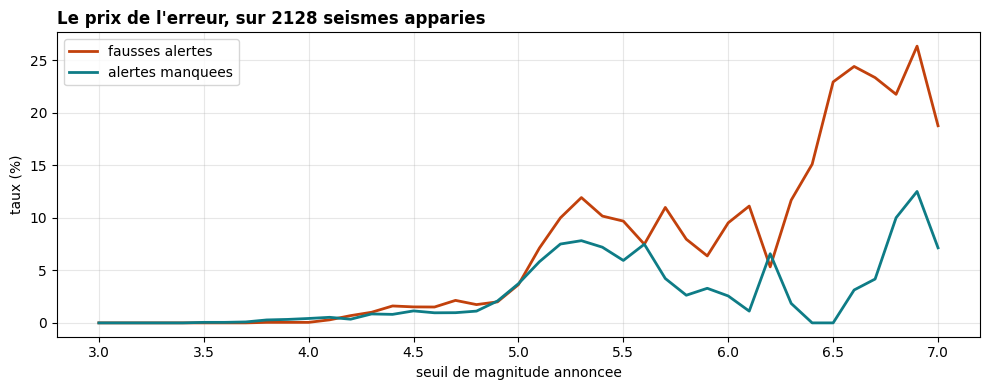

In [7]:
display(curve[curve.threshold.isin([4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])][
    ["threshold", "alertes_emises", "fausse_alerte", "taux_fausse_alerte_pct",
     "alerte_manquee", "taux_manque_pct"]])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(curve.threshold, curve.taux_fausse_alerte_pct,
        color="#C2410C", lw=2, label="fausses alertes")
ax.plot(curve.threshold, curve.taux_manque_pct,
        color="#0E7C86", lw=2, label="alertes manquees")
ax.set_xlabel("seuil de magnitude annoncee")
ax.set_ylabel("taux (%)")
ax.set_title(f"Le prix de l'erreur, sur {len(pairs)} seismes apparies",
             fontweight="bold", loc="left")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()

> **Lecture.** Le taux de fausse alerte **monte avec le seuil** : a M4,0 il est
> de 0,05 %, a M6,5 il atteint 22,9 %. Ce n'est pas un paradoxe. Les seuils
> hauts se situent la ou `mb` sature et ou les echelles divergent le plus ;
> c'est exactement le piege documente en section 4.
>
> Le point de croisement se situe vers **M5,0**, ou les deux taux valent environ
> 3,6 % et 3,7 %. Un service qui refuse par-dessus tout de manquer un seisme
> descendra plus bas et acceptera de declencher pour rien.

---
## 4. Six échelles de magnitude qui ne mesurent pas la même chose

C'est le piège le plus discret du jeu de données. Une M4,9 `ml` et une M4,9
`mww` ne décrivent pas le même phénomène physique.

**Nous ne convertissons pas.** Les formules entre échelles sont régionales et
empiriques : une relation calibrée en Californie ne vaut pas en Indonésie.
Appliquer une formule universelle produirait des nombres d'apparence rigoureuse
et sans fondement.

La couche Silver qualifie donc chaque mesure — famille, seuil de saturation —
au lieu de la transformer.

,magnitude_family,magnitude_type,events,magnitude_avg,magnitude_min,magnitude_max,saturation_threshold,saturated
0,body_wave,mb,15614,4.444,4.00,6.30,6.5,0
1,moment,mww,1437,5.309,4.40,8.80,10.0,0
2,moment,mwr,347,4.374,4.00,5.20,10.0,0
3,local,ml,74,4.169,0.59,5.85,6.5,0
4,duration,md,30,3.677,0.78,4.55,5.0,0
5,moment,mw,27,4.357,4.00,5.70,10.0,0
6,moment,mwb,6,5.783,5.20,6.10,10.0,0
7,surface_wave,ms_vx,1,4.900,4.90,4.90,8.0,0


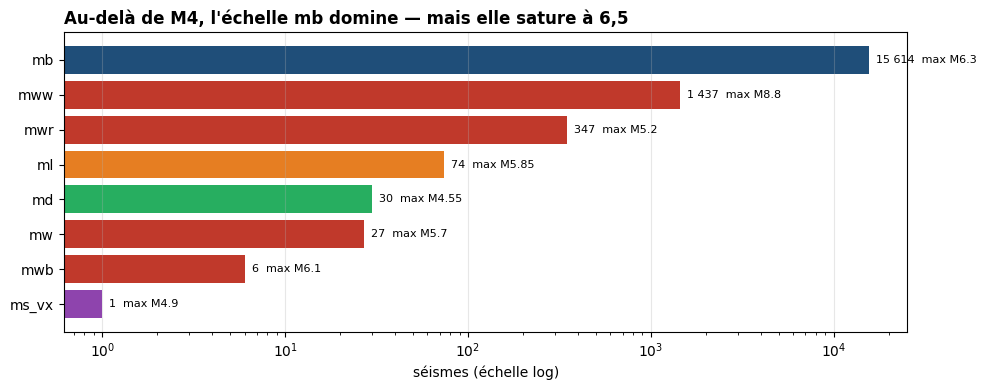

In [8]:
display(scales)

fig, ax = plt.subplots(figsize=(10, 4))
ordered = scales.sort_values("events", ascending=True)
colours = {"body_wave": "#1f4e79", "moment": "#c0392b", "local": "#e67e22",
           "duration": "#27ae60", "surface_wave": "#8e44ad"}
ax.barh(ordered.magnitude_type, ordered.events,
        color=[colours.get(f, "#888") for f in ordered.magnitude_family])
for y, (n, mx) in enumerate(zip(ordered.events, ordered.magnitude_max)):
    ax.text(n, y, f"  {n:,}".replace(",", " ") + f"  max M{mx}", va="center", fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("séismes (échelle log)")
ax.set_title("Au-delà de M4, l'échelle mb domine — mais elle sature à 6,5",
             fontweight="bold", loc="left")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

> **Lecture.** `mb` couvre 89 % des séismes M≥4 mais **sature vers 6,5** : au
> delà, elle sous-estime systématiquement. `mww`, qui ne sature pas, ne
> représente que 10 % des mesures — mais c'est elle qui porte les magnitudes
> extrêmes du jeu, jusqu'à M8,8.
>
> Classer les séismes par `mag` sans tenir compte de `magType` reviendrait donc
> à faire remonter des `mb` moyennes au-dessus de `mww` majeures.
>
> Sur ce jeu limité à 2025, aucune magnitude n'atteint son seuil de saturation :
> le garde-fou est en place mais n'a rien à signaler. Il servira dès qu'un
> millésime contiendra un séisme majeur.

---
## 5. Le modele : ce qu'il predit, et ce qu'il ne predit pas

Les variables connues **a l'instant de l'alerte** — nombre de stations, trou de
couverture azimutal, echelle employee, erreur d'ajustement — suffisent-elles a
anticiper la revision ?

Deux questions ont ete posees au meme jeu de donnees. **Une seule recoit une
reponse utile, et nous publions les deux.**

In [9]:
reg = report["regression"]
cls = report["classification"]

print(f"coupure temporelle : {report['coupure_temporelle']}")
print(f"apprentissage {report['taille_apprentissage']} | test {report['taille_test']}")
print()
print("QUESTION 1 — de combien la magnitude va-t-elle bouger")
print(f"   MAE du modele           : {reg['modele']['mae']:.4f}")
print(f"   MAE si l'on suppose 0   : {reg['references']['toujours_zero']['mae']:.4f}")
print(f"   bat la reference        : {reg['bat_la_reference']}")
print()
print("QUESTION 2 — faut-il se mefier de ce chiffre")
print(f"   aire sous ROC           : {cls['aire_sous_roc']:.4f}   (0,5 = hasard)")
print(f"   part de cas positifs    : {cls['reference']['part_positive_test_pct']} %")
print()
print("variables les plus explicatives :")
for row in reg["importances"][:6]:
    print(f"   {row['variable']:<34} {row['poids']:.4f}")

coupure temporelle : 2025-09-12 03:31:04.097000
apprentissage 1490 | test 638

QUESTION 1 — de combien la magnitude va-t-elle bouger
   MAE du modele           : 0.0775
   MAE si l'on suppose 0   : 0.0510
   bat la reference        : False

QUESTION 2 — faut-il se mefier de ce chiffre
   aire sous ROC           : 0.8328   (0,5 = hasard)
   part de cas positifs    : 3.1 %

variables les plus explicatives :
   first_minutes_since_quake          0.5729
   first_minimum_distance             0.1855
   first_magnitude_station_count      0.0589
   first_magnitude                    0.0544
   first_magnitude_error              0.0261
   first_longitude                    0.0197


> **La regression echoue, et c'est un resultat.** La majorite des seismes ne
> bougent pas : supposer zero revision est une strategie forte qu'un modele
> d'ampleur ne bat pas. L'erreur moyenne recompense le silence.
>
> **La classification, elle, informe** : une aire sous ROC de 0,83 signifie que
> le modele sait ordonner les seismes du plus suspect au moins suspect. Sa
> precision au seuil par defaut reste faible parce que 3 % seulement des cas
> sont positifs — c'est un probleme de calibration, pas de pouvoir predictif.
>
> **Une variable a ete auditee.** Le delai de premiere publication portait 57 %
> du poids du modele. Une importance elevee ne prouve pas une dependance : nous
> avons donc reentraine sans elle (`EXCLUDED_FEATURES`) pour verifier que le
> modele ne repose pas sur un artefact d'archivage de l'USGS.

---
## 6. Le troisieme temoin : les humains sont-ils d'accord avec la machine ?

L'USGS collecte les temoignages du public (`felt`, `cdi`). Une intuition
naturelle veut que, si des gens ont senti un seisme plus fort que ne l'indiquait
la mesure, la magnitude ait ete sous-estimee.

**Cette intuition est fausse dans nos donnees.**

In [10]:
heard = witness[witness.has_witness == True]

print(f"seismes apparies             : {len(witness)}")
print(f"dont >= 5 temoignages humains: {len(heard)}  ({100*len(heard)/len(witness):.1f} %)")
print()

groups = witness.groupby(witness.has_witness.fillna("champ absent")).agg(
    seismes=("event_id", "count"),
    pct_hausse=("moved_up", lambda s: round(100 * s.mean(), 1)),
    pct_baisse=("moved_down", lambda s: round(100 * s.mean(), 1)),
    ecart_absolu_moyen=("shift_abs", lambda s: round(s.mean(), 3)))
display(groups)

comparable = heard[heard.intensity_gap.notna()]
louder = comparable.groupby("witness_louder").agg(
    seismes=("event_id", "count"),
    pct_hausse=("moved_up", lambda s: round(100 * s.mean(), 1)),
    ecart_moyen=("shift", lambda s: round(s.mean(), 3)),
    ecart_intensite=("intensity_gap", lambda s: round(s.mean(), 2)))
display(louder)

seismes apparies             : 2128
dont >= 5 temoignages humains: 305  (14.3 %)



,seismes,pct_hausse,pct_baisse,ecart_absolu_moyen
has_witness,,,,
False,289,4.2,11.4,0.068
True,305,4.9,13.8,0.089
champ absent,1534,4.2,5.2,0.048


,seismes,pct_hausse,ecart_moyen,ecart_intensite
witness_louder,,,,
False,92,6.5,-0.018,-0.84
True,100,3.0,-0.062,0.87


> **Ce que la mesure dit.** Un seisme ressenti par au moins cinq personnes est
> revise a la baisse presque **trois fois plus souvent** qu'un seisme non
> ressenti. L'explication tient au piege des echelles : les seismes ressentis
> sont proches des zones peuplees, donc annonces par des reseaux regionaux en
> `ml` ou `md`, que le moment global corrige ensuite vers le bas.
>
> **Ce que la mesure ne dit pas.** Quand le ressenti humain depasse la mesure
> instrumentale, la magnitude n'est pas relevee ensuite — elle baisse un peu
> plus. L'ecart est faible (0,044 de magnitude) sur une centaine de seismes par
> groupe : **nous le presentons comme une hypothese plausible refutee, pas comme
> un effet etabli.**

---
## Ce que ces donnees permettent, et ce qu'elles ne permettent pas

**Etabli, sur 17 526 seismes du catalogue et 2 128 historiques complets :**

- la premiere solution archivee parait **17,8 minutes** apres le seisme en
  mediane ; la fiche se stabilise **75 jours** plus tard ;
- **34,5 %** des seismes voient leur magnitude bouger entre deux versions ;
- 6,6 % portent la trace d'une solution automatique remplacee, et **tous** ont
  vu leur identifiant changer — une jointure naive les compterait deux fois ;
- le seuil d'alerte est desormais **chiffre** : de 0,05 % de fausses alertes a
  M4,0 jusqu'a 22,9 % a M6,5 ;
- un modele peut dire **s'il faut se mefier** d'un chiffre (ROC 0,83), pas
  **de combien** il se trompera.

**Ce qui reste hors de portee.**

L'echantillon de 2 128 seismes est une fraction du catalogue : la recolte
appelle l'API une fois par seisme et prend pres de deux heures. L'architecture
ne change pas d'une ligne pour en traiter dix fois plus — c'est un choix de
temps de calcul, pas une limite de conception.

La cohorte temoin a permis de **mesurer** le biais de selection plutot que de
l'ignorer : les seismes ayant conserve un identifiant `usauto` portent 4,48
versions en moyenne contre 2,89 pour un tirage aleatoire. Un modele entraine
sur la seule cohorte tracee aurait appris sur une population particuliere sans
que personne ne le sache.